# 1. Vidurkio prognozė (privalomas baseline)

**Failas:** `winequality/baselines.py` → `mean_predictor`

Tai paprasčiausias atskaitos metodas: ignoruojami visi laboratoriniai matavimai.
Prognozė visiems mėginiams lygi mokymo aibės kokybės vidurkiui. Jei intelektualusis
metodas nepranoksta šio MAE, požymiai neneša naudingos informacijos (arba skaidymas neteisingas).


## Formulė

\[
\hat y = \bar y_{\mathrm{mok}} = \frac{1}{N}\sum_{i=1}^{N} y_i
\]

Čia \(y_i\) — ekspertų kokybės balas (mediana iš ≥ 3 degustatorių), \(N\) — mokymo mėginių skaičius.
Naudojimo metu \(X\) nenaudojamas — tik vektoriaus ilgis, kad būtų tiek pat prognozių.


## Duomenys (tas pats užšaldytas skaidymas visiems modeliams)


In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
root = here if (here / "winequality").exists() else here.parent
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "notebooks"))

from nb_pagalba import paruošti, metrikos_lentele, artefaktas
from winequality.config import FEATURE_NAMES, SPLIT_SEED

KIND = "red"  # pakeiskite į "white", jei norite balto vyno
duom = paruošti(KIND)
X_tr, y_tr, X_te, y_te = duom["X_tr"], duom["y_tr"], duom["X_te"], duom["y_te"]
print(f"{KIND}: mokymo n={duom['n_train']}, testo n={duom['n_test']}, sėkla={SPLIT_SEED}")
print("Požymiai:", FEATURE_NAMES)


red: mokymo n=1279, testo n=320, sėkla=0
Požymiai: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## Įgyvendinimas ir mokymas


In [2]:
from winequality.baselines import mean_predictor

modelis = mean_predictor(y_tr)
print("Išmoktas vidurkis μ =", modelis.get_params()["mu"])

# Tas pats rankiniu būdu — formulės ir kodo sutapimas:
mu = float(np.mean(y_tr))
assert abs(mu - modelis.get_params()["mu"]) < 1e-12
print("Rankinis μ sutampa su mean_predictor.")


Išmoktas vidurkis μ = 5.63408913213448
Rankinis μ sutampa su mean_predictor.


## Vertinimas testinėje aibėje


,modelis,MAE,MAE (apvalinta),Acc_0.5,Acc_1.0,κ_w,makro-F1
0,vidurkis,0.6837,0.6562,0.4,0.825,0.0,0.3014


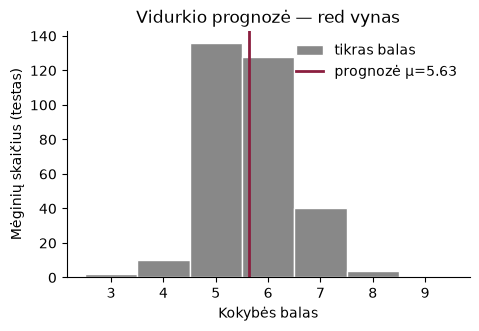

In [3]:
f = modelis.predict(X_te)
lentele = metrikos_lentele(y_te, f, "vidurkis")
display(lentele.round(4))

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.hist(y_te, bins=np.arange(2.5, 9.6, 1), color="#888888", edgecolor="white", label="tikras balas")
ax.axvline(mu, color="#8b1e3f", lw=2, label=f"prognozė μ={mu:.2f}")
ax.set_xlabel("Kokybės balas")
ax.set_ylabel("Mėginių skaičius (testas)")
ax.set_title(f"Vidurkio prognozė — {KIND} vynas")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Ką stebėti

- MAE turėtų būti apie **0,68** raudonam ir **0,67** baltam (balų sklaida aplink vidurkį).
- Acc_1.0 vis tiek būna aukštas, nes dauguma vynų yra 5–6, o vidurkis irgi ~5,6–5,9.
- Makro-F1 prastas: visos prognozės krenta į klasę „vidutinė“.
